In [47]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

In [ ]:

u = mda.Universe("fit.tpr", "fit.xtc")


popg_lipids = u.select_atoms("resname POPE and name PO4")


start_frame = 0  
end_frame = 60000  
numBinsX = 65
numBinsY = 65
box_dim = u.dimensions[:3]

popg_density = np.zeros((numBinsX, numBinsY))

In [49]:
q_subunit = u.select_atoms("resid 1-155 and protein")
fusion_helix = u.select_atoms("resid 156-190 and protein")
m_subunit = u.select_atoms("resid 191-616 and protein ")

In [ ]:
u.trajectory[1000]  
q_coords = q_subunit.positions[:, :2]
fusion_coords = fusion_helix.positions[:, :2]
m_coords = m_subunit.positions[:, :2]

In [ ]:
n_frames = 0  
for ts in u.trajectory[start_frame:end_frame]:
    n_frames += 1

   
    popg_positions = popg_lipids.positions 

   
    pope_hist, xedges, yedges = np.histogram2d(
        popg_positions[:, 0], popg_positions[:, 1],
        bins=[numBinsX, numBinsY], range=[[0, box_dim[0]], [0, box_dim[1]]]
    )

    
    popg_density += pope_hist


popg_density /= n_frames
popg_normal_density= popg_density/7 

np.savetxt('popg_density_avg.txt', popg_density)

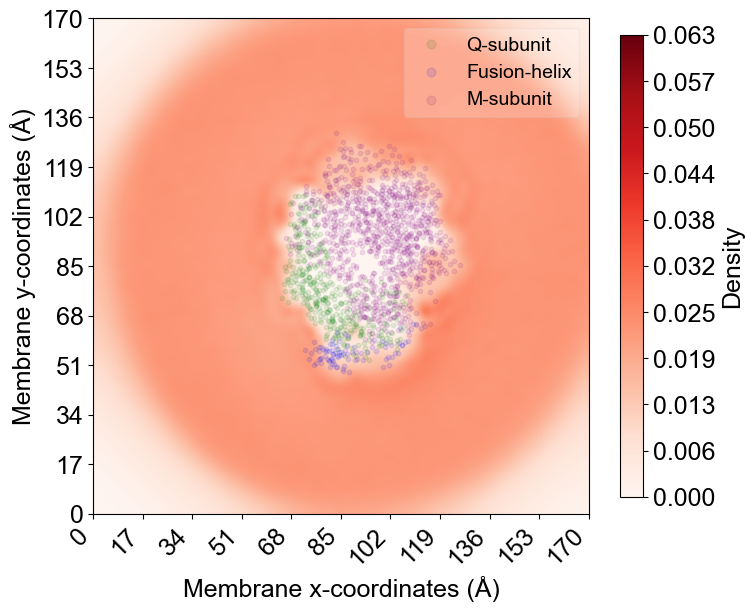

In [ ]:


plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 18 
plt.rcParams["font.weight"] = "regular"



auto = 'no'  
fixed_min = 0.0
fixed_max = 0.063

fig, ax = plt.subplots(figsize=(8, 8))


if auto == 'yes':
    plot = ax.imshow(popg_normal_density.T, interpolation='bicubic', origin='lower', extent=(0, box_dim[0], 0, box_dim[1]), cmap='viridis')
elif auto == 'no':
    plot = ax.imshow(popg_normal_density.T, interpolation='bicubic', origin='lower', extent=(0, box_dim[0], 0, box_dim[1]), cmap='Reds', vmin=fixed_min, vmax=fixed_max)


cbar = fig.colorbar(plot, ticks=np.linspace(fixed_min, fixed_max, 11), shrink=0.75, aspect=20)
cbar.ax.set_ylabel('Density')
from matplotlib.ticker import FormatStrFormatter
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))


#ax.set_title('POPG Density in the Membrane')
ax.set_xlabel('Membrane x-coordinates (Å)')
ax.set_ylabel('Membrane y-coordinates (Å)')


num_ticks = 6
xticks = np.linspace(0, box_dim[0], 11, dtype=int)
yticks = np.linspace(0, box_dim[1], 11, dtype=int)
ax.set_xticks(xticks)
ax.set_yticks(yticks)
ax.set_xticklabels([str(int(x)) for x in xticks], rotation=45, ha='right')
ax.set_yticklabels([str(int(y)) for y in yticks])

#ax.set_xticklabels([f'{val:.2f}' for val in xticks], rotation=45, ha='right')
#ax.set_yticklabels([f'{val:.2f}' for val in yticks])

ax.scatter(q_coords[:, 0], q_coords[:, 1], s=10, c='green',alpha= 0.1,  label='Q-subunit')
ax.scatter(fusion_coords[:, 0], fusion_coords[:, 1], s=10, c='blue',alpha= 0.1, label='Fusion-helix')
ax.scatter(m_coords[:, 0], m_coords[:, 1], s=10, c='purple',alpha= 0.1, label='M-subunit')
ax.legend(fontsize=14,       
    markerscale=2,           
    loc='upper right',
    frameon= True,
    framealpha=0.2,       
    fancybox=True  )

#ax.scatter(q_coords[:, 1], q_coords[:, 0], s=10, c='red',alpha= 0.2, label='Q-subunit')
#ax.scatter(fusion_coords[:, 1], fusion_coords[:, 0], s=10, c='blue',alpha=0.2, label='Fusion-helix')
#ax.scatter(m_coords[:, 1], m_coords[:, 0], s=10, c='green',alpha=0.2, label='M-subunit')
#ax.legend()


plt.savefig('pope_density_normal_with_region_bold.pdf',dpi=600)
plt.show()